In [1]:
import pandas as pd
import numpy as np

In [2]:
def safe_convert(col):
    col_cleaned = col.replace(',', '', regex=True)
    return pd.to_numeric(col_cleaned, errors='coerce')

setpt = pd.read_csv('setpoint_publish(in).csv')
setpt = setpt.apply(lambda col: safe_convert(col) if col.name != 'var' else col)
setpt.columns = setpt.columns.str.strip() #delete whitespace in csv file
setpt

,var,opt_mean,opt_sig,drift_mean,drift_sig,excursion_mean,excursion_sig
0,x1,22.1,0.295,22.111,0.442,22.115,0.5900
1,x2,44.8,1.045,46.010,1.840,46.547,2.3270
2,x4,0.4,0.023,0.368,0.027,0.304,0.0670
3,x5,150000.0,8000.000,135000.000,9000.000,120000.000,16000.0000
4,x7,1206.0,48.240,1266.300,75.978,1266.300,88.6410
5,x8,87.0,5.220,91.176,6.686,107.880,12.2264
6,x9,454.0,19.673,456.270,22.814,599.280,69.9160
7,x17,5492.0,256.293,5526.050,349.983,5552.410,425.6850
8,x3,NaN,NaN,39.000,2.860,NaN,NaN
9,x6,NaN,NaN,112.000,6.720,NaN,NaN


In [3]:
number_of_wafers = 5000

def generate_normal_data(mean, std_dev, size=number_of_wafers, seed=None):
    return np.random.normal(loc=mean, scale=std_dev, size=size)

In [4]:
from scipy.stats import skewnorm

def generate_skewed_data(mean, sig, alpha, size=number_of_wafers):
    return skewnorm.rvs(a=alpha, loc=mean, scale=sig, size=number_of_wafers)

In [5]:
datasets = {}
for data_name in ["opt", "drift", "excursion"]:
    rows = []
    for var, mean, sig in zip(setpt['var'], setpt[f'{data_name}_mean'], setpt[f'{data_name}_sig']):
        if data_name=="excursion" and var in ["x4","x5"]:
            rows.append(generate_skewed_data(mean, sig, alpha=200))
        elif data_name=="excursion" and var=="x8":
            rows.append(generate_skewed_data(mean, sig, alpha=-100))
        elif data_name=="excursion" and var=="x9":
            rows.append(generate_skewed_data(mean, sig, alpha=-200))
        else:
            rows.append(generate_normal_data(mean, sig, seed=42))
    
    datasets[data_name] = pd.DataFrame(np.column_stack(rows), columns=setpt['var'])

In [6]:
opt_data = datasets['opt']
drift_data = datasets['drift']
exc_data = datasets['excursion']

# Outcome 

In [7]:
#function from first task sheet
#opt_data['outcome'] = -( 4 * np.pi * opt_data['x1'] + (77 / 100) * (opt_data['x2'] ** 2) +
#   58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 33.5 * opt_data['x7'] ) / (8 * 10**5)

opt_data['outcome'] = (-( 5 * np.pi * 10**4 * opt_data['x1'] + 770 * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 730.5 * opt_data['x7'] ) / (8 * 10**5) + 7.5)

#function from first task sheet
#drift_data['outcome'] = (-( 4 * np.pi * drift_data['x1'] + (77 / 100) * (drift_data['x2'] ** 2) +
#    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 33.5 * drift_data['x7'] ) / (8 * 10**5)) 
#+ (19 * drift_data['x5'] * drift_data['x9'] * drift_data['x8'] / (10**11))

drift_data['outcome'] = (-( 5 * np.pi * 10**4 * opt_data['x1'] + 770 * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 730.5 * opt_data['x7'] ) / (8 * 10**5) 
    + (39 * drift_data['x5'] * drift_data['x9'] * drift_data['x8']) / (10**11) + 7) 

#function from first task sheet
#exc_data['outcome'] = (-( 4 * np.pi * exc_data['x1'] + (77 / 100) * (exc_data['x2'] ** 2) +
#    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 33.5 * exc_data['x7'] ) / (8 * 10**5)) 
#+ ((19 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11)) 
#+ ((0.8 * exc_data['x4'] * (exc_data['x5']**2) * exc_data['x17'] ) / (10**13))

exc_data['outcome'] = (-( 5 * np.pi * 10**4 * opt_data['x1'] + 770 * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 730.5 * opt_data['x7'] ) / (8 * 10**5) 
    + (39 * drift_data['x5'] * drift_data['x9'] * drift_data['x8']) / (10**11) + 7 
    + ((0.8 * exc_data['x4'] * (exc_data['x5'])**2 * exc_data['x17'] ) / (10**13)))


In [8]:
opt_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,22.038290,44.424790,0.386975,156624.312025,1256.611026,81.954748,454.605330,5928.716567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.327293
1,21.832284,45.543741,0.413226,154007.334056,1187.451927,90.009121,468.474747,5491.017038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.627367
2,22.151702,46.144883,0.384792,135406.502415,1177.346231,100.402971,448.129968,5580.485621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.456758
3,22.241877,45.987001,0.416742,145743.581723,1215.977732,89.394428,445.374913,5310.530207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.491476
4,22.136744,45.112696,0.385508,154743.770675,1216.963237,92.374010,459.229591,5535.043728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.916139


In [9]:
drift_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,21.924106,47.432782,0.352861,144140.261344,1313.263766,95.325937,457.976469,5160.055906,38.335906,127.420667,546.181350,8.458342,13228.014148,322.566678,8018.417676,27.277627,657.857427,123893.654819,6415.943221,4.281461
1,22.332140,48.585938,0.412278,129886.170612,1309.439373,83.247136,405.661048,5404.644189,41.030881,105.056303,562.893829,8.440488,14528.990065,360.080344,8783.315075,29.360098,650.167681,126895.412083,6271.349470,2.838013
2,22.721704,45.540216,0.347664,128209.671090,1135.693061,104.349572,456.562240,5077.747221,34.440093,121.554379,574.197222,8.604337,15011.423405,310.763141,8286.105172,25.443575,640.741413,112585.256043,5895.296070,4.338947
3,21.923380,46.441031,0.381895,119131.059052,1266.555739,95.772015,463.704132,6150.168370,39.728602,107.172704,561.157083,7.988394,13588.872654,340.169776,9502.994992,29.074785,658.257030,124561.644155,6783.052159,3.054809
4,21.725553,46.075186,0.368878,131671.717320,1130.585486,86.524740,425.865583,6284.166308,36.642362,107.949409,561.916056,7.548309,14080.411676,376.037295,8363.543773,26.481009,674.710286,116776.202155,7061.543181,3.308352


In [10]:
exc_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,21.734515,44.009520,0.317423,120828.004913,1096.364323,101.254513,559.361857,5585.466367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.352187
1,21.447115,46.116957,0.347426,136524.534373,1189.693015,100.963905,579.039516,5341.034621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.604946
2,21.263185,45.194687,0.323287,135570.634254,1211.976792,94.300281,532.831998,5904.781932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.145756
3,22.183513,47.106609,0.327083,123754.608225,1214.058785,99.713535,504.564217,5008.386813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.061908
4,22.334847,44.292505,0.307336,122814.852732,1315.328754,106.550928,539.464334,5584.833832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.379521


In [11]:
opt_data.to_csv("data/opt_data.csv", index=None)
drift_data.to_csv("data/drift_data.csv", index=None)
exc_data.to_csv("data/excursion_data.csv", index=None)

# Visualize Kernel Density Plot

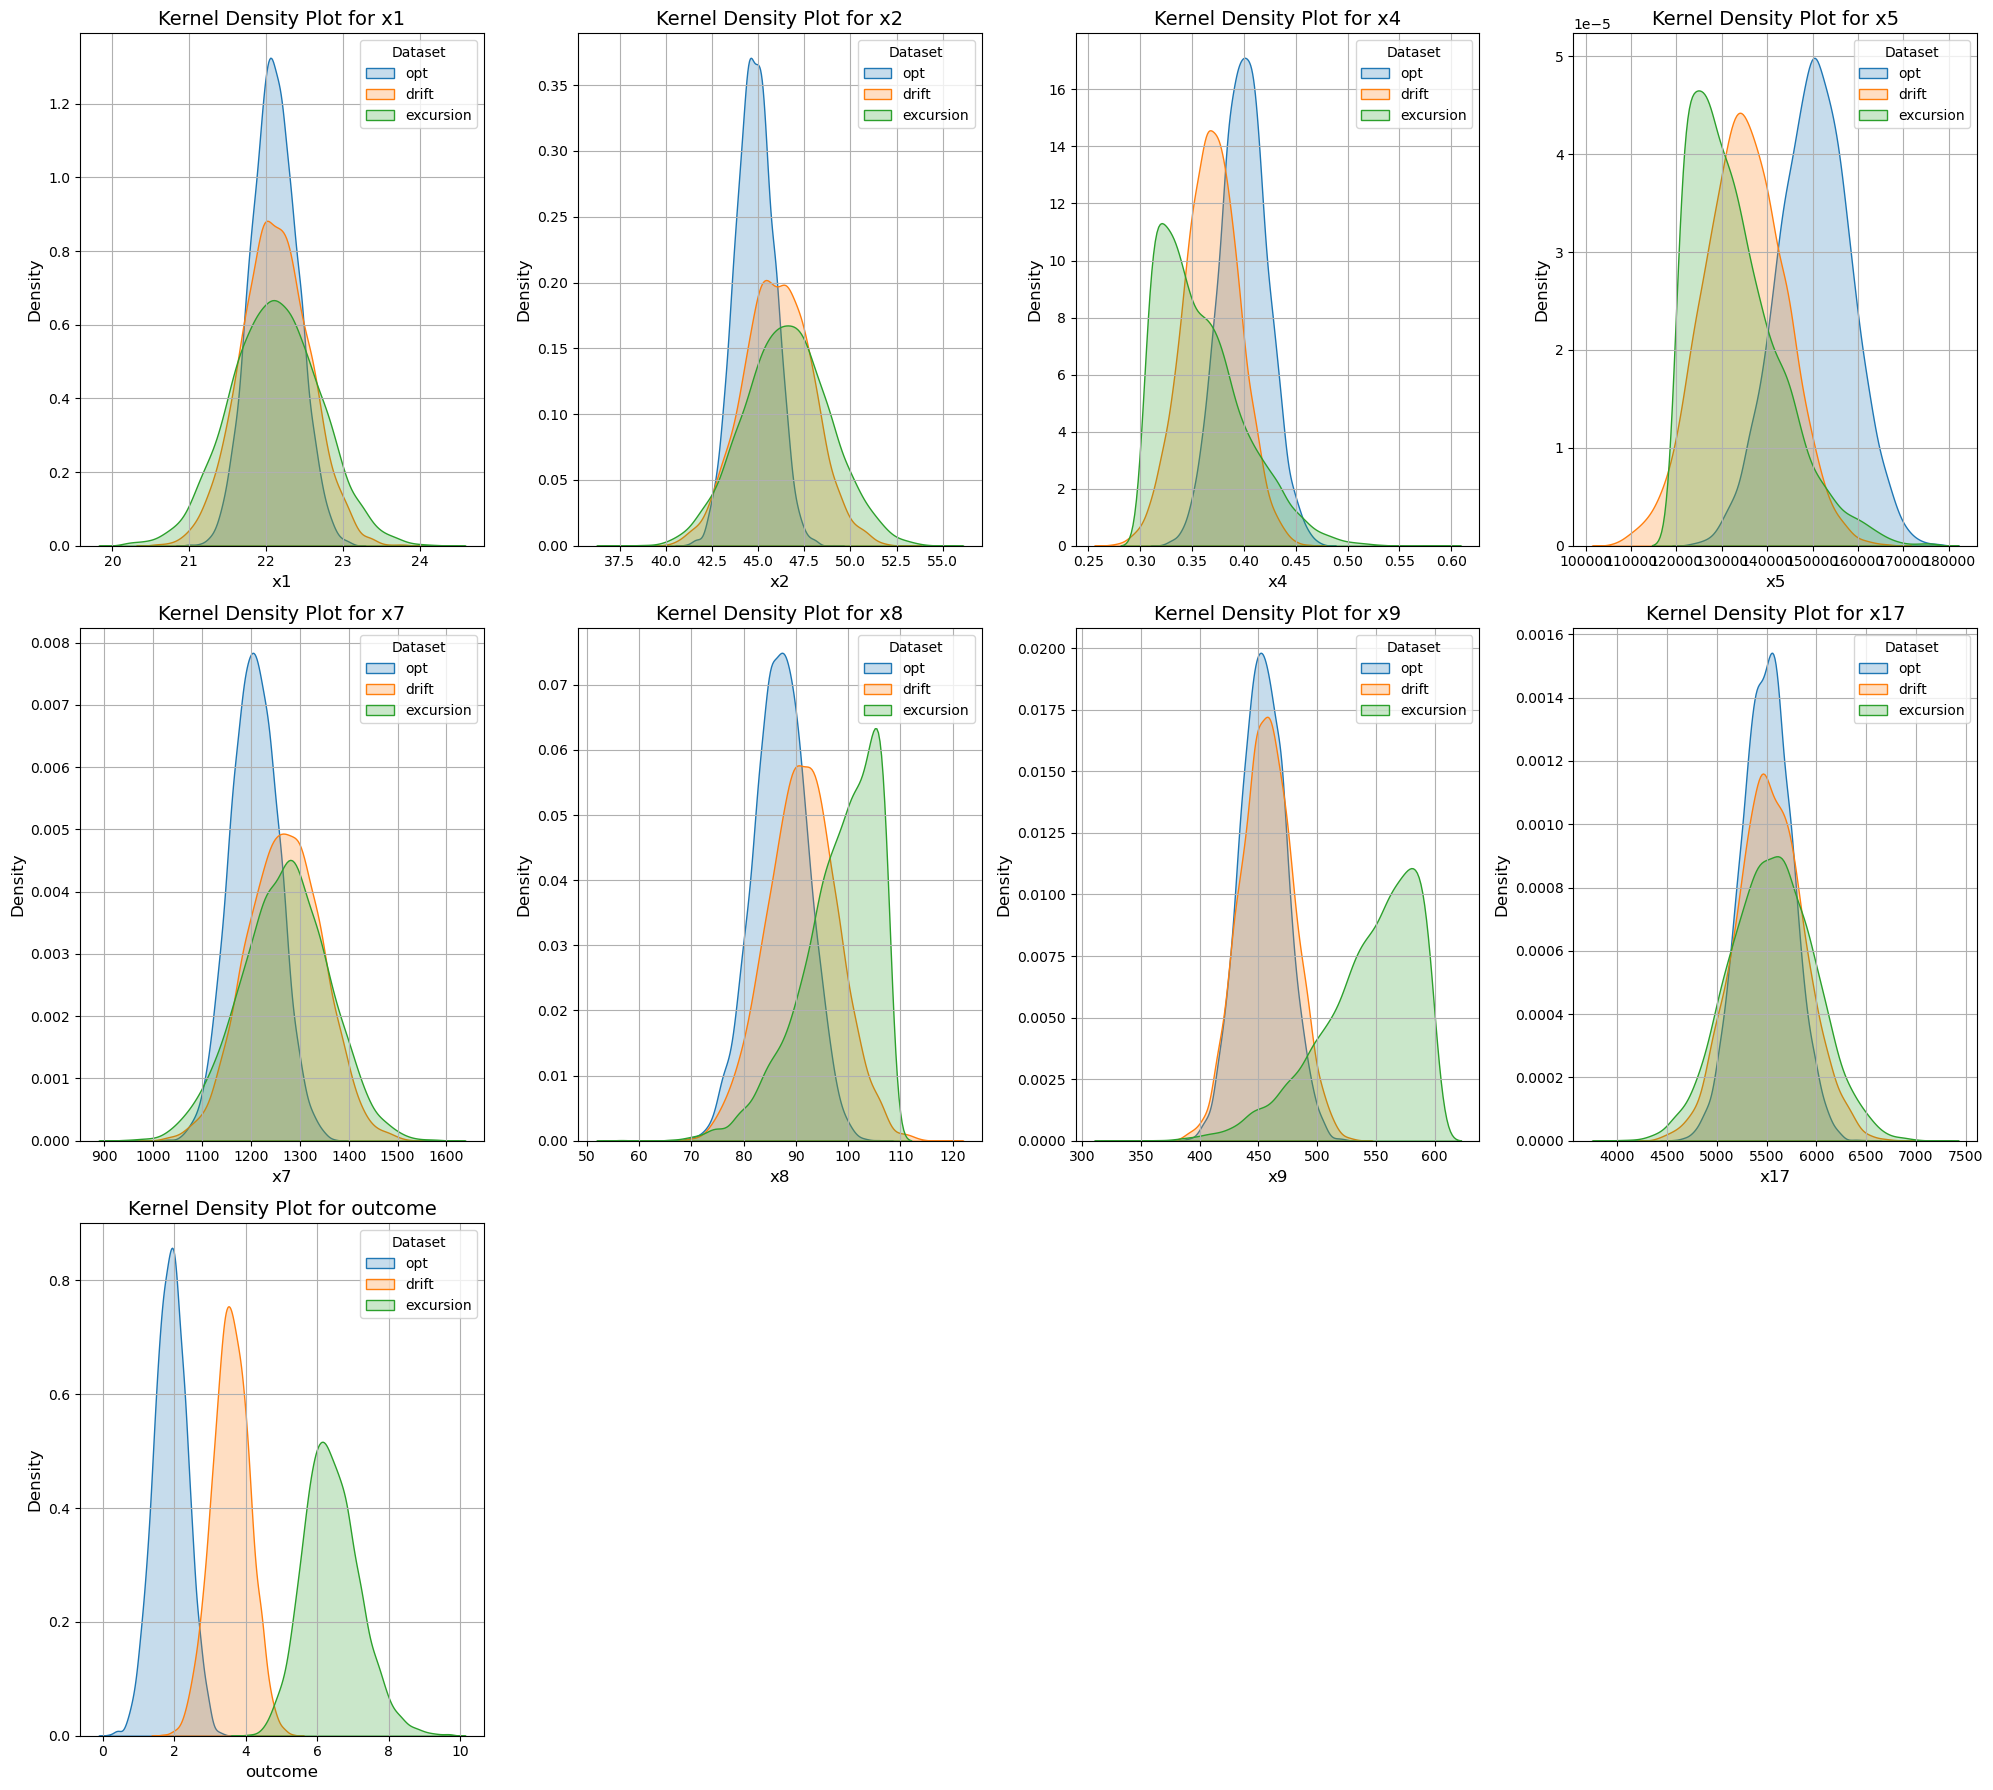

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {
    'opt': opt_data,
    'drift': drift_data,
    'excursion': exc_data
}

variables = opt_data.columns.drop([' x3 ', ' x6 ',' x10 ', ' x11 ', ' x12 ', ' x13 ', ' x14 ', ' x15 ', ' x16 ', ' x18 ',' x19 '])

plots_per_row = 4

num_variables = len(variables)
num_rows = (num_variables + plots_per_row - 1) // plots_per_row 

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, 6 * num_rows))
axes = axes.flatten()  

for i, variable in enumerate(variables):
    ax = axes[i]
    for name, df in datasets.items():
        sns.kdeplot(df[variable], label=name, fill=True, ax=ax)
    ax.set_title(f'Kernel Density Plot for {variable}', fontsize=14)
    ax.set_xlabel(variable, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(title='Dataset')
    ax.grid(True)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Sanity Check
Correlation

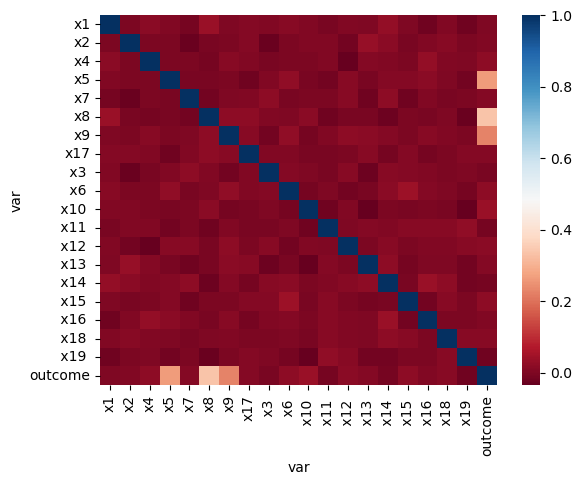

In [13]:
corr = drift_data.corr()

sns.heatmap(corr, 
            cmap='RdBu', 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)
plt.show()

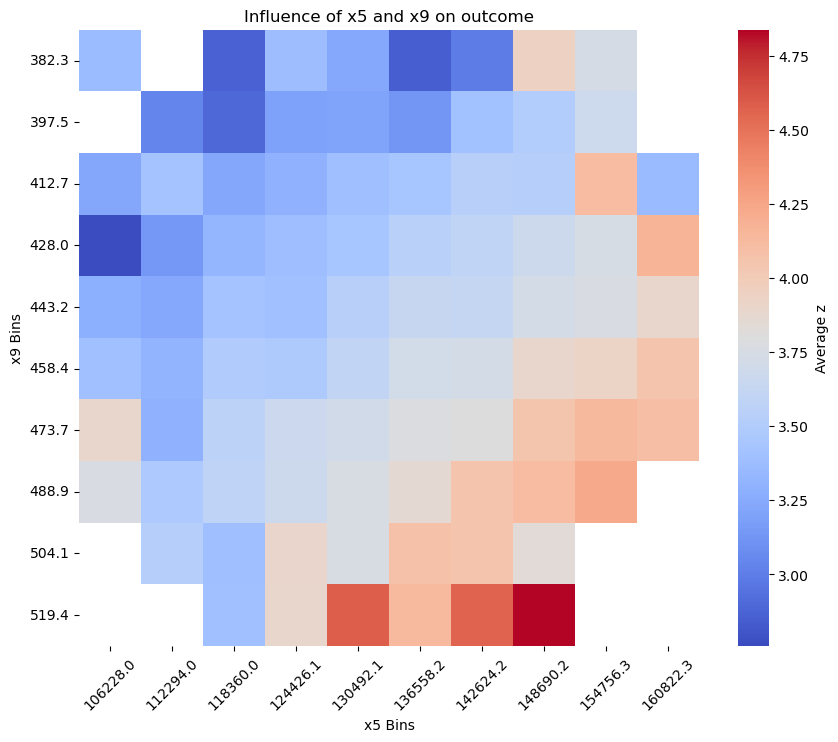

In [ ]:
# Create a DataFrame
data = drift_data

# Define the number of bins for x and y
n_bins = 10
x_bins = np.linspace(data["x5"].min(), data["x5"].max(), n_bins + 1)
y_bins = np.linspace(data["x9"].min(), data["x9"].max(), n_bins + 1)

# Categorize x and y into bins
data['x5_bin'] = pd.cut(data['x5'], bins=x_bins, labels=False, include_lowest=True)
data['x9_bin'] = pd.cut(data['x9'], bins=y_bins, labels=False, include_lowest=True)

# Compute the average outcome value for each bin pair
heatmap_data = data.groupby(['x5_bin', 'x9_bin'])['outcome'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Average outcome'})
plt.title("Influence of x5 and x9 on outcome")
plt.xlabel("x5 Bins")
plt.ylabel("x9 Bins")
plt.xticks(ticks=np.arange(len(x_bins) - 1) + 0.5, labels=[f"{x_bins[i]:.1f}" for i in range(len(x_bins) - 1)], rotation=45)
plt.yticks(ticks=np.arange(len(y_bins) - 1) + 0.5, labels=[f"{y_bins[i]:.1f}" for i in range(len(y_bins) - 1)], rotation=0)
plt.show()
